## Waste Detection and Classification System

In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [23]:
# path comes from kagglehub.dataset_download(...)
import os
dataset_path = "Waste_Dataset"

# sanity check
print("Dataset path:", dataset_path)
print("Path exists:", os.path.exists(dataset_path))

# list classes
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

print(f"Number of classes: {num_classes}")
print(f"Classes: {classes}")

Dataset path: Waste_Dataset
Path exists: True
Number of classes: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


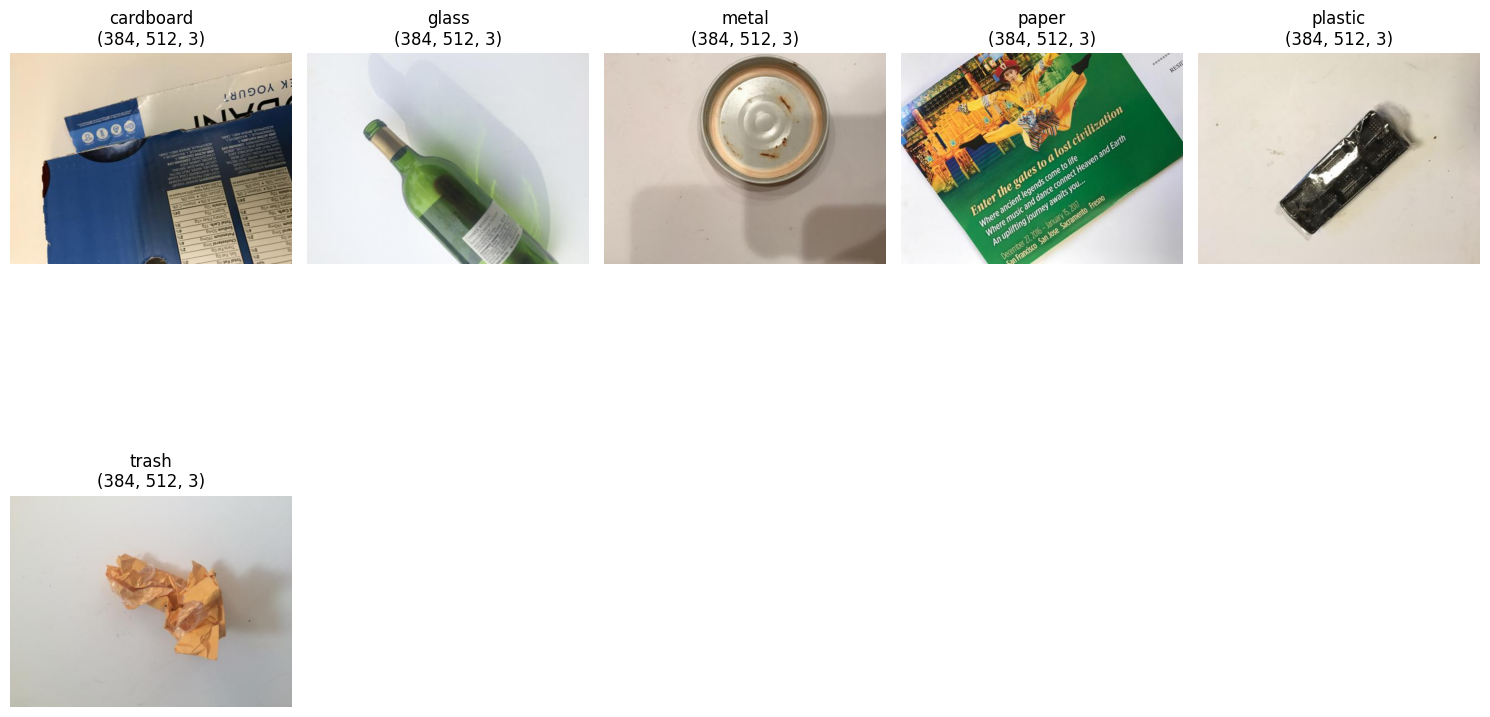

In [24]:
import random

def visualize_sample_images(dataset_path, classes, num_images=10):
    plt.figure(figsize=(15, 10))

    cols = 5
    rows = (num_images + cols - 1) // cols

    for i, class_name in enumerate(classes[:num_images]):
        class_path = os.path.join(dataset_path, class_name)
        img_list = os.listdir(class_path)

        if not img_list:
            continue

        try:
            img_name = random.choice(img_list)
            img_path = os.path.join(class_path, img_name)
            img = plt.imread(img_path)

            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.title(f'{class_name}\n{img.shape}')
            plt.axis('off')

        except Exception as e:
            print(f"Error loading image from {class_name}: {e}")

    plt.tight_layout()
    plt.show()
visualize_sample_images(dataset_path, classes)

In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Define image size and batch_size
img_size = 224
batch_size = 32

# Slightly improved Data Augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [32]:
from tensorflow.keras.optimizers import Adam

# Load MobileNetV2 as the base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model weights, training
base_model.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x) # output layer

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# Model summary
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [34]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 193ms/step - accuracy: 0.7147 - loss: 0.7924 - val_accuracy: 0.6938 - val_loss: 0.7768
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 352ms/step - accuracy: 0.7419 - loss: 0.7243 - val_accuracy: 0.6958 - val_loss: 0.7895
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 27s 418ms/step - accuracy: 0.7514 - loss: 0.7023 - val_accuracy: 0.7197 - val_loss: 0.7854
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 449ms/step - accuracy: 0.7472 - loss: 0.6876 - val_accuracy: 0.7078 - val_loss: 0.7849
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 24s 373ms/step - accuracy: 0.7555 - loss: 0.7187 - val_accuracy: 0.7396 - val_loss: 0.7488
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 364ms/step - accuracy: 0.7585 - loss: 0.6583 - val_accuracy: 0.7018 - val_loss: 0.7501
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 23s 353ms/step - accuracy: 0.7684 - loss: 0.6879 - val_accuracy: 0.7097 - val_loss: 0.7448
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 28s 444ms/step - accuracy: 0.7667 - loss: 0.6599 - val_accu

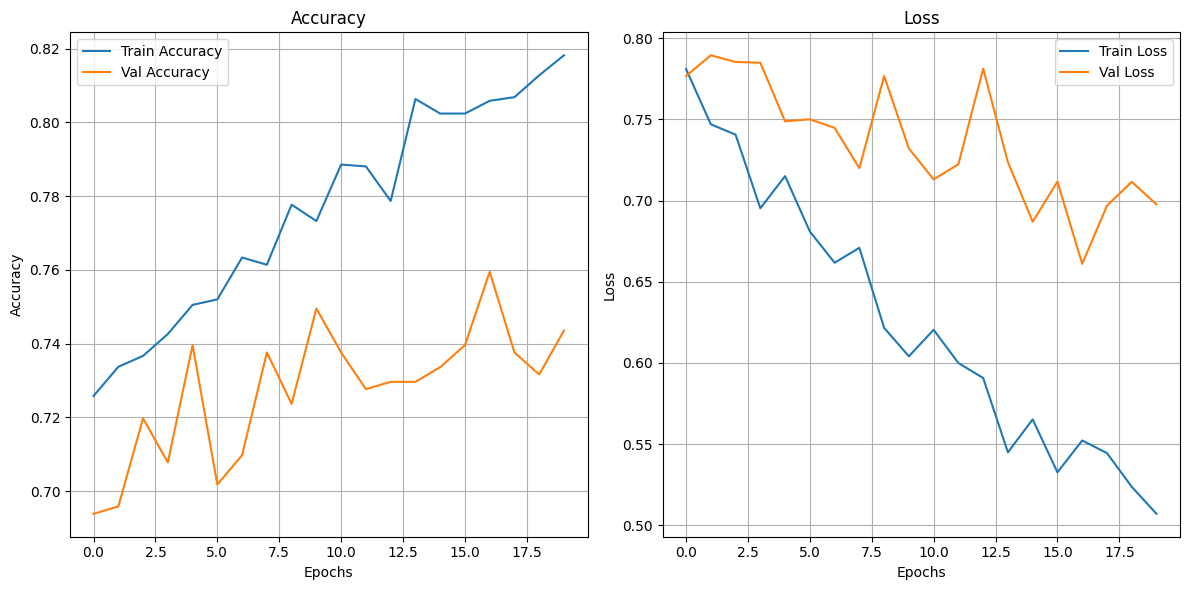

In [35]:
plt.figure(figsize=(12, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history.get('accuracy', []), label='Train Accuracy')
plt.plot(history.history.get('val_accuracy', []), label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history.get('loss', []), label='Train Loss')
plt.plot(history.history.get('val_loss', []), label='Val Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()